In [20]:
from nilearn.datasets import fetch_neurovault_motor_task


motor_data = fetch_neurovault_motor_task(data_dir="./neurovault", verbose=1)

[fetch_neurovault_motor_task] Dataset found in neurovault\neurovault


C:\Users\ducat\AppData\Local\Temp\ipykernel_16764\3369181751.py:4: FutureWarning: The 'fetch_neurovault_motor_task' function will be removed in version>0.13.1. 
Please use 'load_sample_motor_activation_image' instead.'
  motor_data = fetch_neurovault_motor_task(data_dir="./neurovault", verbose=1)


Image shape : (53, 63, 46)
Nilearn version : 0.13.1


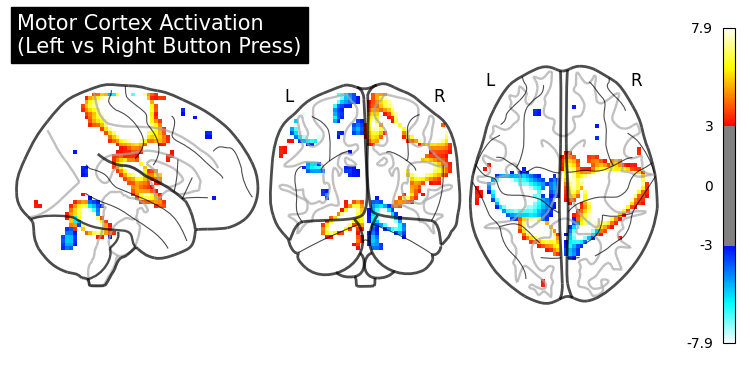

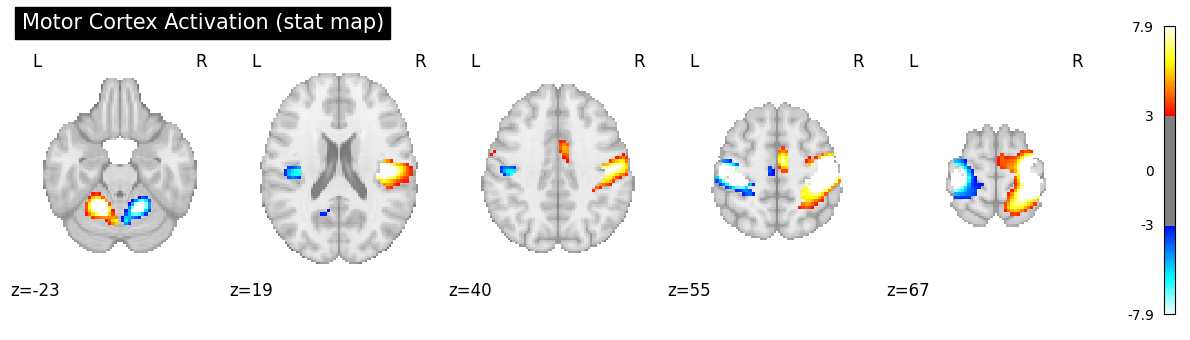

In [21]:
import nilearn
from nilearn import datasets, plotting, image

motor_img = motor_data.images[0]  # 3D statistical map

print(f"Image shape : {nilearn.image.load_img(motor_img).shape}")
print(f"Nilearn version : {nilearn.__version__}")

# ─────────────────────────────────────────────
# 2. Display on a glass brain (3 orientations)
# ─────────────────────────────────────────────
plotting.plot_glass_brain(
    motor_img,
    threshold=3,           # Z-score threshold
    colorbar=True,
    title="Motor Cortex Activation\n(Left vs Right Button Press)",
    display_mode="ortho",  # axial + coronal + sagittal
    plot_abs=False,        # show both + and - activations
    cmap="cold_hot",
)

# ─────────────────────────────────────────────
# 3. Display on a anatomical background (MNI)
# ─────────────────────────────────────────────
plotting.plot_stat_map(
    motor_img,
    threshold=3,
    colorbar=True,
    title="Motor Cortex Activation (stat map)",
    display_mode="z",      # axial slices
    cut_coords=5,          # number of slices
    cmap="cold_hot",
)

plotting.show()

[fetch_localizer_first_level] Dataset found in neurovault\localizer_first_level
fMRI image shape : (53, 63, 46, 128)
Repetition time  : 2.4s

Event conditions available:
neurovault\localizer_first_level\localizer_first_level\sub-12069_task-localizer_events.tsv

Fitting GLM...
GLM fitted successfully!

Design matrix columns:
['audio_computation', 'audio_left_hand_button_press', 'audio_right_hand_button_press', 'horizontal_checkerboard', 'sentence_listening', 'sentence_reading', 'vertical_checkerboard', 'visual_computation', 'visual_left_hand_button_press', 'visual_right_hand_button_press', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'drift_6', 'constant']


C:\Users\ducat\AppData\Local\Temp\ipykernel_16764\2499681467.py:53: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


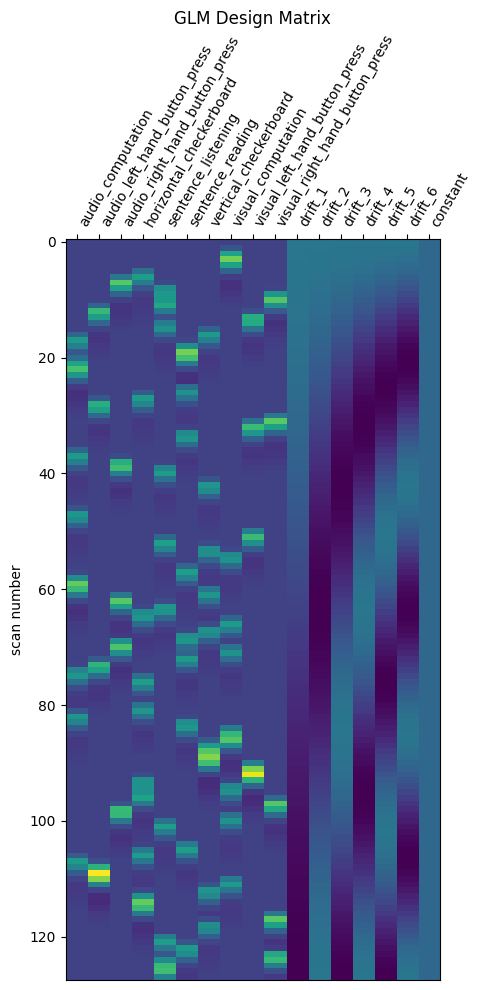


Available conditions: ['audio_computation', 'audio_left_hand_button_press', 'audio_right_hand_button_press', 'horizontal_checkerboard', 'sentence_listening', 'sentence_reading', 'vertical_checkerboard', 'visual_computation', 'visual_left_hand_button_press', 'visual_right_hand_button_press', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'drift_6', 'constant']

Contrast vector: [ 0.  1. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]


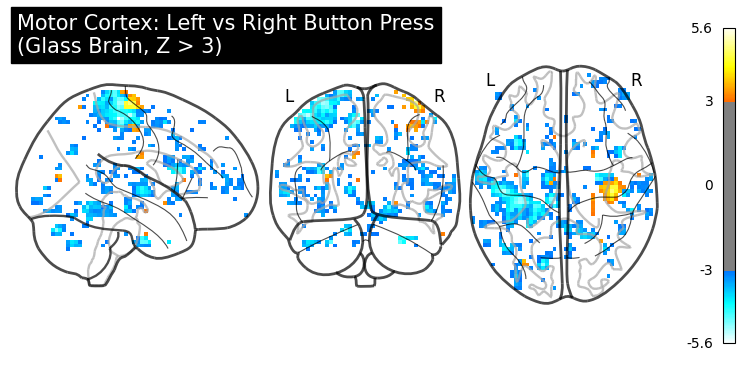

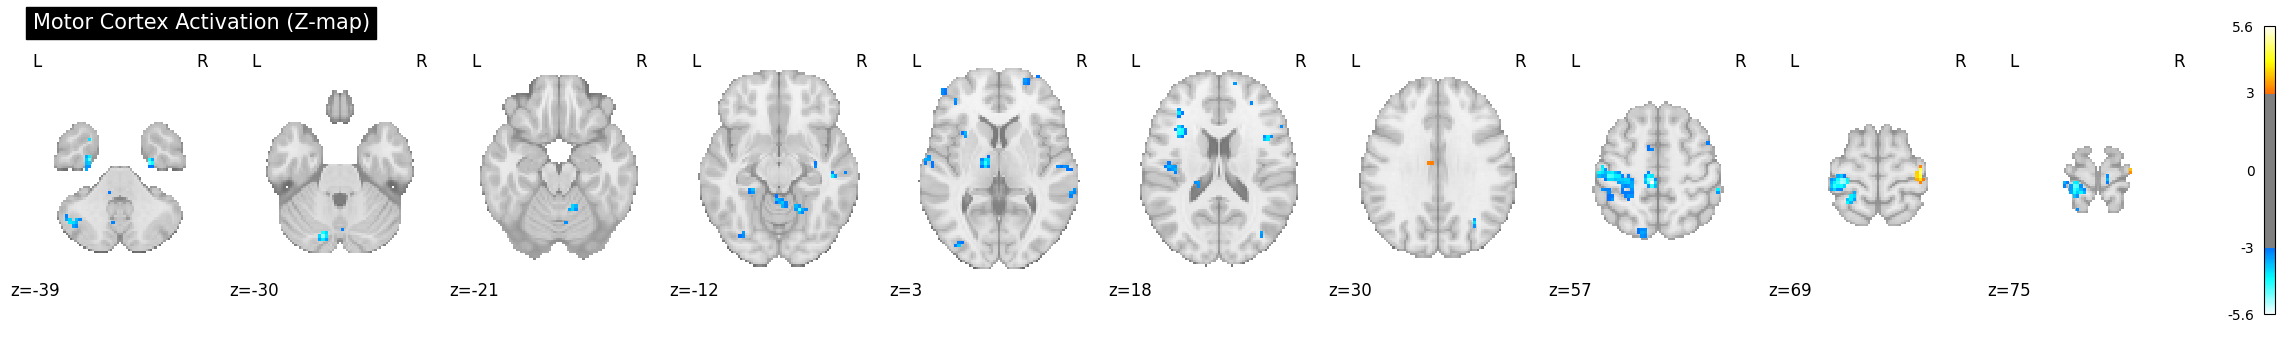

C:\Users\ducat\AppData\Local\Temp\ipykernel_16764\2499681467.py:124: FutureWarning: From release 0.15.0, make_glm_report will be deprecated. Use generate_report method of the GLM model instead.
  report = make_glm_report(



Report saved to motor_glm_report.html


C:\Users\ducat\AppData\Local\Temp\ipykernel_16764\2499681467.py:124: UserWarning: 
'threshold=3.0' is not used with 'height_control='fpr''.
'threshold' is only used when 'height_control=None'. 
'threshold' was set to 'None'. 
  report = make_glm_report(


In [22]:
import numpy as np
from nilearn import datasets, plotting, image
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
from nilearn.reporting import make_glm_report
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 1. Fetch raw fMRI data (Localizer dataset)
#    Contains motor tasks: button press,
#    visual/audio stimulation, etc.
# ─────────────────────────────────────────────
localizer_data = datasets.fetch_localizer_first_level(data_dir="./neurovault", verbose=1)

fmri_img    = localizer_data.epi_img       # 4D raw fMRI data
events      = localizer_data.events        # stimulus timing (pandas DataFrame)
t_r         = localizer_data.t_r           # repetition time (seconds)

print(f"fMRI image shape : {image.load_img(fmri_img).shape}")
print(f"Repetition time  : {t_r}s")
print(f"\nEvent conditions available:\n{events}")

# ─────────────────────────────────────────────
# 2. Set up the First Level GLM
#    (same setup as nilearn's tutorial)
# ─────────────────────────────────────────────
glm = FirstLevelModel(
    t_r=t_r,
    noise_model="ar1",          # autoregressive noise model
    standardize=False,
    hrf_model="spm",            # SPM canonical HRF
    drift_model="cosine",       # cosine drift removal
    high_pass=0.01,             # 0.01 Hz high-pass filter
    minimize_memory=False
)

# ─────────────────────────────────────────────
# 3. Fit the GLM to the fMRI data
# ─────────────────────────────────────────────
print("\nFitting GLM...")
glm.fit(fmri_img, events)
print("GLM fitted successfully!")

# ─────────────────────────────────────────────
# 4. Inspect the Design Matrix
# ─────────────────────────────────────────────
design_matrix = glm.design_matrices_[0]

print(f"\nDesign matrix columns:\n{list(design_matrix.columns)}")

from nilearn.plotting import plot_design_matrix
plot_design_matrix(design_matrix)
plt.title("GLM Design Matrix")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 5. Define Motor Contrast
#    "left-right button press" contrast
#    targeting contralateral motor cortex
# ─────────────────────────────────────────────

# Check available conditions
conditions = design_matrix.columns.tolist()
print(f"\nAvailable conditions: {conditions}")

# Build contrast vector:
# +1 for left button press, -1 for right button press
contrast_def = {
    "audio_left_hand_button_press"  :  1,
    "audio_right_hand_button_press" : -1,
}

# Create contrast vector aligned to design matrix columns
contrast_vector = np.zeros(len(conditions))

for condition, weight in contrast_def.items():
    if condition in conditions:
        contrast_vector[conditions.index(condition)] = weight
    else:
        print(f"Warning: '{condition}' not found in design matrix!")

print(f"\nContrast vector: {contrast_vector}")

# ─────────────────────────────────────────────
# 6. Compute the Contrast (Z-map)
# ─────────────────────────────────────────────
motor_contrast = glm.compute_contrast(
    contrast_vector,
    stat_type="t",          # t-statistic
    output_type="z_score",  # convert to Z-score map
)

# ─────────────────────────────────────────────
# 7. Visualize Results
# ─────────────────────────────────────────────

# --- Glass Brain View ---
plotting.plot_glass_brain(
    motor_contrast,
    threshold=3.0,
    colorbar=True,
    plot_abs=False,
    cmap="cold_hot",
    title="Motor Cortex: Left vs Right Button Press\n(Glass Brain, Z > 3)",
    display_mode="ortho",
)

# --- Stat Map on anatomical slices ---
plotting.plot_stat_map(
    motor_contrast,
    threshold=3.0,
    colorbar=True,
    cmap="cold_hot",
    title="Motor Cortex Activation (Z-map)",
    display_mode="z",
    cut_coords=10,
)

plotting.show()

# ─────────────────────────────────────────────
# 8. Generate Full HTML GLM Report
# ─────────────────────────────────────────────
report = make_glm_report(
    glm,
    contrasts={"Left vs Right Button Press": contrast_vector},
    title="Motor Cortex GLM Report",
    threshold=3.0,
    plot_type="glass",
)

report.save_as_html("motor_glm_report.html")
print("\nReport saved to motor_glm_report.html")


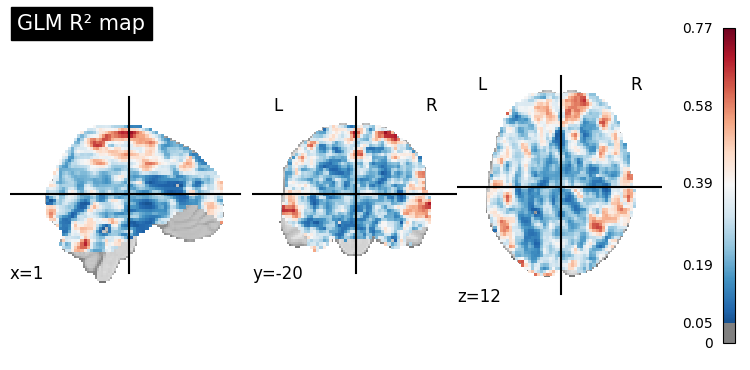

In [23]:
from nilearn import plotting

# This shows voxel-wise R² — is the model working anywhere?
plotting.plot_stat_map(glm.r_square[0],
                       threshold=0.05,
                       title="GLM R² map")
plotting.show()

D:\github\scz_familiarity_fMRI_ML\.venv\lib\site-packages\numpy\_core\fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



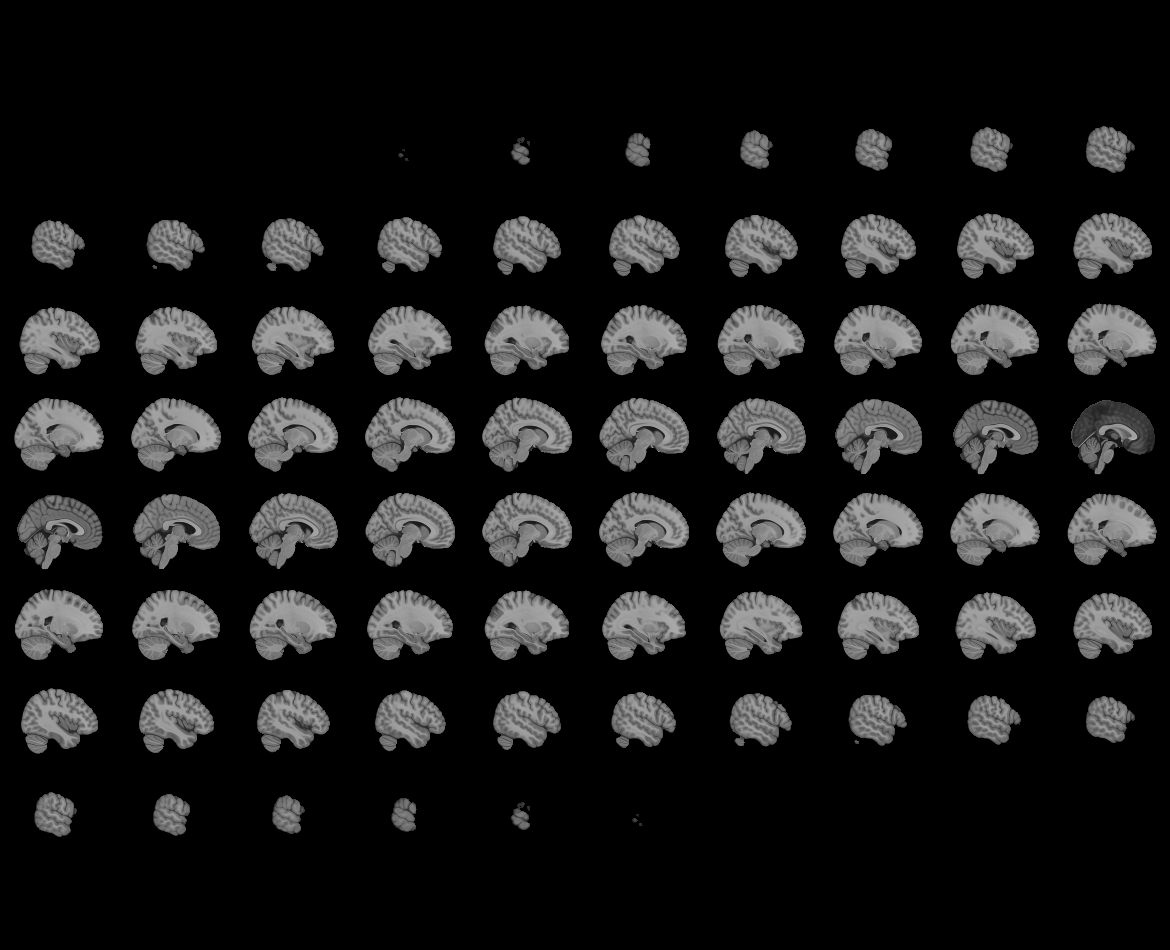
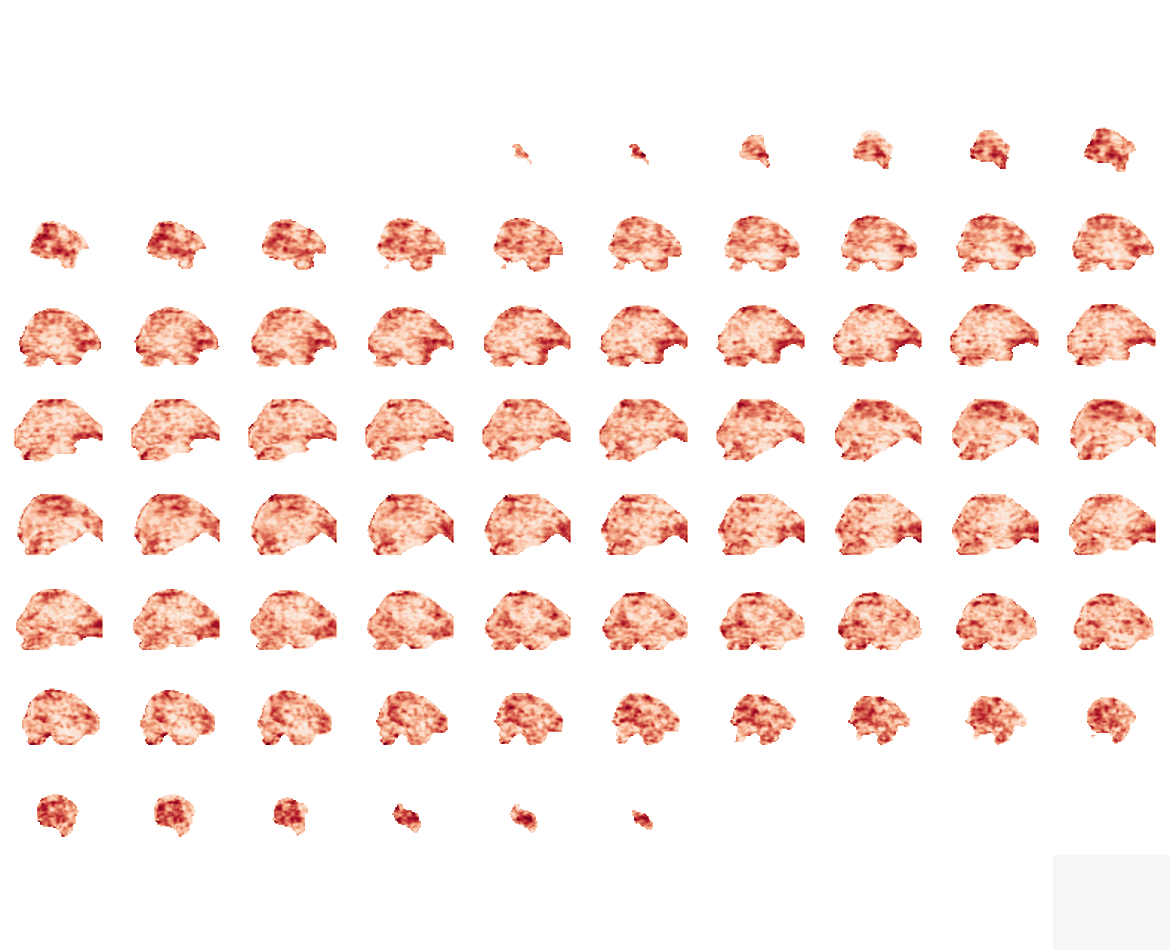

In [25]:
plotting.view_img(glm.r_square[0])

In [18]:
import sys
import pandas as pd


sys.path.append("..")

import numpy as np
from nilearn.reporting import get_clusters_table
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_stat_map
from brain_map import find_region_names

from nilearn import datasets

import matplotlib.pyplot as plt
import lib.mni_to_atlas as mni_to_atlas

mni_to_atlas._ATLASES_PATH = "../lib"

atlas = mni_to_atlas.AtlasBrowser("AAL3")


reg = []

clean, threshold = threshold_stats_img(motor_contrast, height_control=None, threshold=3.0, cluster_threshold=0)
#        clean, threshold = threshold_stats_img(z_score, alpha=0.05, height_control="bonferroni", cluster_threshold=5)
table = get_clusters_table(clean, stat_threshold=threshold, cluster_threshold=0)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(table)

pos = [np.array([x,y,z]) for (x,y,z) in zip(table['X'], table['Y'], table['Z'])]

for p, size in zip(pos, table['Cluster Size (mm3)']):
    try:
        projected_coords = atlas.project_to_nearest(p)
        projected_regions = atlas.find_regions(projected_coords)
        print(p, "=>", projected_coords, "=>", projected_regions, size)

        reg.append(*projected_regions)
    except Exception as e:
        print(e)


C:\Users\ducat\AppData\Local\Temp\ipykernel_16764\1580555604.py:25: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  clean, threshold = threshold_stats_img(motor_contrast, height_control=None, threshold=3.0, cluster_threshold=0)


   Cluster ID     X     Y     Z  Peak Stat Cluster Size (mm3)
0           1  39.0 -21.0  69.0   4.889782               1026
1           2 -30.0 -75.0  12.0   3.659844                108
2           3  30.0 -18.0  75.0   3.658924                 54
3           4  36.0 -18.0  51.0   3.614838                540
4          4a  33.0 -27.0  51.0   3.317144                   
5           5  -9.0 -15.0  27.0   3.487282                108
6           6  24.0 -27.0  78.0   3.399487                135
7           7  30.0 -60.0  66.0   3.385641                 27
8           8  24.0   6.0  -9.0   3.256887                 54
9           9  60.0  -9.0 -33.0   3.094066                 27
10         10  24.0 -36.0  51.0   3.056147                 54
11         11 -36.0  -9.0 -15.0   3.029800                 27
12         12  -6.0  21.0   9.0   3.021331                 27
[ 39. -21.  69.] => [ 39 -21  69] => ['Precentral_R'] 1026
[-30. -75.  12.] => [-31 -75  12] => ['Occipital_Mid_L'] 108
[ 30. -18.  

In [17]:
from collections import defaultdict
import pandas

mni_regions = defaultdict(lambda: defaultdict(float))

co_name = 'a'
reg = 'b'

mni_regions[co_name][reg] += 2

print(pd.DataFrame(mni_regions))

     a
b  2.0


In [12]:
reg

['Precentral_R',
 'Occipital_Mid_L',
 'Precentral_R',
 'Precentral_R',
 'Precentral_R',
 'Cingulate_Mid_L',
 'Precentral_R',
 'Parietal_Sup_R',
 'Putamen_R',
 'Temporal_Inf_R',
 'Postcentral_R',
 'Temporal_Sup_L',
 'Caudate_L']